In [0]:
import warnings
warnings.filterwarnings('ignore')

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from utils import *

from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    average_precision_score,
    recall_score,
    precision_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [0]:
COLUNA_ALVO = 'Class'
RANDOM_STATE = 42

In [0]:
df = pd.read_csv('./creditcard.csv', delimiter=',')
print("Shape:", df.shape)
print("Columns:", df.columns)

X = df.drop(COLUNA_ALVO, axis=1)
y= df[COLUNA_ALVO]

Shape: (284807, 31)
Columns: Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [0]:
# Check class distribution
distribution = df['Class'].value_counts()
print(distribution)

distribution = df['Class'].value_counts(normalize=True) * 100
print(distribution)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [0]:
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), ['Time', 'Amount'])
    ],
    remainder='passthrough'
)

In [0]:
pipeline_rfc_undersampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

pipeline_lr_undersampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=500, n_jobs=-1))
])

pipeline_knn_undersampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('model', KNeighborsClassifier(n_jobs=-1))
])

pipeline_xgb_undersampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('model', xgb.XGBClassifier(seed=RANDOM_STATE, n_jobs=-1))
])

In [0]:
pipeline_rfc_oversampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

pipeline_lr_oversampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=500, n_jobs=-1))
])

pipeline_knn_oversampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('model', KNeighborsClassifier(n_jobs=-1))
])

pipeline_xgb_oversampling = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('model', xgb.XGBClassifier(seed=RANDOM_STATE, n_jobs=-1))
])

In [0]:
param_grid_rfc = {
    'model__n_estimators': [30, 100, 300, None],
    'model__max_depth': [7, 10, None],
    'model__min_samples_leaf': [1, 5]
}

param_grid_lr = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [0.01, 0.1, 1.0],
    'model__solver': ['liblinear', 'saga']
}

param_grid_knn = {
    'model__n_neighbors': [3, 5, 7],
    'model__weights': ['uniform', 'distance']
}

param_grid_xgb = {
    "model__booster": ['gbtree', 'gblinear', 'dart'],
    "model__max_depth": [3, 5, 10, 50],
    "model__learning_rate": [0.1, 0.01, 0.05],
    "model__n_estimators": [30, 100, 300],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

In [0]:
models_to_run_undersampling = {
    'RandomForest': {
        'estimator': pipeline_rfc_undersampling,
        'param_grid': param_grid_rfc
    },
    'LogisticRegression': {
        'estimator': pipeline_lr_undersampling,
        'param_grid': param_grid_lr
    },
    'KNN': {
        'estimator': pipeline_knn_undersampling,
        'param_grid': param_grid_knn
    },
    'XGBoost': {
        'estimator': pipeline_xgb_undersampling,
        'param_grid': param_grid_xgb
    }
}

In [0]:
models_to_run_oversampling = {
    'RandomForest': {
        'estimator': pipeline_rfc_oversampling,
        'param_grid': param_grid_rfc
    },
    'LogisticRegression': {
        'estimator': pipeline_lr_oversampling,
        'param_grid': param_grid_lr
    },
    'KNN': {
        'estimator': pipeline_knn_oversampling,
        'param_grid': param_grid_knn
    },
    'XGBoost': {
        'estimator': pipeline_xgb_oversampling,
        'param_grid': param_grid_xgb
    }
}

In [0]:
def avaliar_modelos_nested_cv(models_to_run, X, y, verbose=True, plot_cm=True):
    all_model_results = {}

    for model_name, config in models_to_run.items():

        if verbose:
            print("\n\n" + "=" * 46)
            print(f"      INICIANDO AVALIAÇÃO: {model_name}      ")
            print("=" * 46)

        pipeline = config['estimator']
        param_grid = config['param_grid']

        # Cross-validations
        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        
        if model_name == 'RandomForest':
            grid_search = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                cv=inner_cv,
                scoring='roc_auc',
                verbose=1 if verbose else 0
            )
        else:
            grid_search = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                cv=inner_cv,
                scoring='roc_auc',
                verbose=1 if verbose else 0,
                n_jobs=-1
            )

        outer_roc_auc_scores = []
        outer_avg_precision_scores = []
        outer_recall_scores = []
        outer_precision_scores = []
        outer_f1_scores = []
        all_y_test, all_y_pred = [], []
        all_y_test, all_y_pred = [], []

        # Loop Externo
        fold_num = 1
        for train_idx, test_idx in outer_cv.split(X, y):
            if verbose:
                print(f"\n\n{model_name} - Fold Externo {fold_num}/{outer_cv.get_n_splits()}")

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            grid_search.fit(X_train, y_train)
            best_model = grid_search.best_estimator_

            if verbose:
                print(f"Melhores parâmetros: {grid_search.best_params_}")

            y_pred = best_model.predict(X_test)
            y_pred_proba = best_model.predict_proba(X_test)[:, 1]

            roc_auc = roc_auc_score(y_test, y_pred_proba)
            avg_precision = average_precision_score(y_test, y_pred_proba)
            recall = recall_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)

            outer_roc_auc_scores.append(roc_auc)
            outer_avg_precision_scores.append(avg_precision)
            outer_recall_scores.append(recall)
            outer_precision_scores.append(precision)
            outer_f1_scores.append(f1)
            all_y_test.extend(y_test)
            all_y_pred.extend(y_pred)


            if verbose:
                print(f"Fold {fold_num} - ROC-AUC: {roc_auc:.4f} | Avg. Precision: {avg_precision:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f} | F1: {f1:.4f}")

            fold_num += 1
            
        # Resultados agregados
        mean_roc_auc = np.mean(outer_roc_auc_scores)
        std_roc_auc = np.std(outer_roc_auc_scores)
        mean_avg_precision = np.mean(outer_avg_precision_scores)
        std_avg_precision = np.std(outer_avg_precision_scores)
        mean_recall = np.mean(outer_recall_scores)
        std_recall = np.std(outer_recall_scores)
        mean_precision = np.mean(outer_precision_scores)
        std_precision = np.std(outer_precision_scores)
        mean_f1 = np.mean(outer_f1_scores)
        std_f1 = np.std(outer_f1_scores)

        if verbose:
            print(f"\n\n--- Avaliação Final para: {model_name} ---")
            print(f"Média ROC-AUC:        {mean_roc_auc:.4f} ± {std_roc_auc:.4f}")
            print(f"Média Avg. Precision: {mean_avg_precision:.4f} ± {std_avg_precision:.4f}")
            print(f"Média Recall:         {mean_recall:.4f} ± {std_recall:.4f}")
            print(f"Média Precision:      {mean_precision:.4f} ± {std_precision:.4f}")
            print(f"Média F1-Score:       {mean_f1:.4f} ± {std_f1:.4f}")

        # Matriz de confusão consolidada
        all_y_test_np = np.array(all_y_test)
        all_y_pred_np = np.array(all_y_pred)
        cm = confusion_matrix(all_y_test_np, all_y_pred_np)

        if verbose:
            print("\nMatriz de Confusão (Consolidada):")
            print(cm)
            print(f"Total de Fraudes Reais: {np.sum(all_y_test_np == 1)}")
            print(f"Total de Fraudes Pegas (VP): {cm[1, 1]}")
            print(f"Total de Fraudes Perdidas (FN): {cm[1, 0]}")

            print("\nRelatório de Classificação:")
            print(classification_report(
                all_y_test_np,
                all_y_pred_np,
                target_names=['Classe 0 (Normal)', 'Classe 1 (Fraude)']
            ))

        # Plot da Matriz de Confusão
        if plot_cm:
            plt.figure(figsize=(5, 4))
            sns.heatmap(
                cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=['Pred: Normal', 'Pred: Fraud'],
                yticklabels=['Real: Normal', 'Real: Fraud']
            )
            plt.title(f'Confusion Matrix - {model_name}')
            plt.ylabel('Real')
            plt.xlabel('Predicted')
            plt.tight_layout()
            plt.show()

        # Resultados médios
        report_dict = classification_report(all_y_test_np, all_y_pred_np, output_dict=True)
        all_model_results[model_name] = {
            'mean_roc_auc': mean_roc_auc,
            'mean_precision': mean_precision,
            'mean_recall': mean_recall,
            'mean_f1_score': mean_f1,
            'std_roc_auc': std_roc_auc,
            'std_precision': std_precision,
            'std_recall': std_recall,
            'std_f1_score': std_f1
        }

    results_df = pd.DataFrame(all_model_results).T

    if verbose:
        print("\n\n" + "=" * 55)
        print("      SUMÁRIO FINAL - COMPARAÇÃO DOS MODELOS      ")
        print("=" * 55)
        print("(Métricas médias calculadas a partir dos 5 folds do Nested CV)")
        print(results_df)

    return results_df



      INICIANDO AVALIAÇÃO: RandomForest      


RandomForest - Fold Externo 1/5
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Melhores parâmetros: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 30}
Fold 1 - ROC-AUC: 0.9734 | Avg. Precision: 0.7156 | Recall: 0.8889 | Precision: 0.0478 | F1: 0.0908


RandomForest - Fold Externo 2/5
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Melhores parâmetros: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Fold 2 - ROC-AUC: 0.9856 | Avg. Precision: 0.7615 | Recall: 0.9192 | Precision: 0.0867 | F1: 0.1584


RandomForest - Fold Externo 3/5
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Melhores parâmetros: {'model__max_depth': 7, 'model__min_samples_leaf': 5, 'model__n_estimators': 300}
Fold 3 - ROC-AUC: 0.9870 | Avg. Precision: 0.7155 | Recall: 0.8980 | Precision: 0.0808 | F1: 0.1483


RandomForest - Fold Externo 4/5
Fitting 5 folds fo

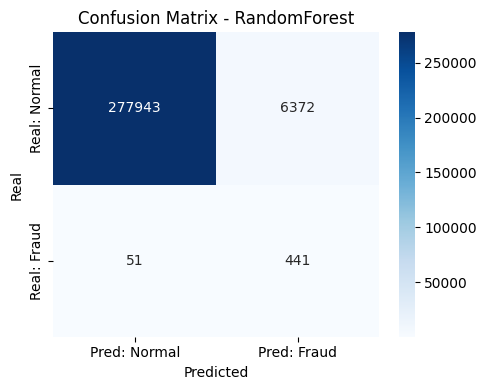



      INICIANDO AVALIAÇÃO: LogisticRegression      


LogisticRegression - Fold Externo 1/5
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores parâmetros: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'saga'}
Fold 1 - ROC-AUC: 0.9854 | Avg. Precision: 0.6696 | Recall: 0.8485 | Precision: 0.1143 | F1: 0.2014


LogisticRegression - Fold Externo 2/5
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores parâmetros: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Fold 2 - ROC-AUC: 0.9837 | Avg. Precision: 0.7513 | Recall: 0.9394 | Precision: 0.0412 | F1: 0.0789


LogisticRegression - Fold Externo 3/5
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores parâmetros: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'saga'}
Fold 3 - ROC-AUC: 0.9859 | Avg. Precision: 0.7221 | Recall: 0.8878 | Precision: 0.1343 | F1: 0.2332


LogisticRegression - Fold Externo 4/5
Fitting 5 folds for each of 12 

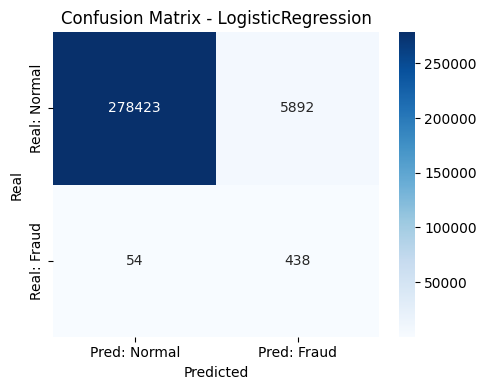



      INICIANDO AVALIAÇÃO: KNN      


KNN - Fold Externo 1/5
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Melhores parâmetros: {'model__n_neighbors': 7, 'model__weights': 'distance'}
Fold 1 - ROC-AUC: 0.9736 | Avg. Precision: 0.5855 | Recall: 0.8586 | Precision: 0.0803 | F1: 0.1468


KNN - Fold Externo 2/5
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Melhores parâmetros: {'model__n_neighbors': 7, 'model__weights': 'distance'}
Fold 2 - ROC-AUC: 0.9759 | Avg. Precision: 0.5563 | Recall: 0.9192 | Precision: 0.0675 | F1: 0.1257


KNN - Fold Externo 3/5
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Melhores parâmetros: {'model__n_neighbors': 7, 'model__weights': 'distance'}
Fold 3 - ROC-AUC: 0.9835 | Avg. Precision: 0.4787 | Recall: 0.8776 | Precision: 0.0770 | F1: 0.1416


KNN - Fold Externo 4/5
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Melhores parâmetros: {'model__n_neighbors': 7, 'model__weights': 'distance'}
Fold 4 - ROC-

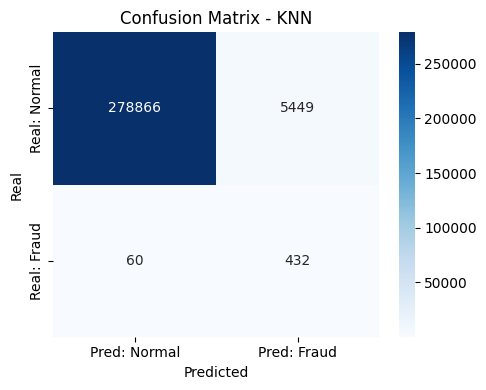



      INICIANDO AVALIAÇÃO: XGBoost      


XGBoost - Fold Externo 1/5
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Melhores parâmetros: {'model__booster': 'gbtree', 'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Fold 1 - ROC-AUC: 0.9848 | Avg. Precision: 0.7409 | Recall: 0.8889 | Precision: 0.0480 | F1: 0.0911


XGBoost - Fold Externo 2/5
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Melhores parâmetros: {'model__booster': 'dart', 'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Fold 2 - ROC-AUC: 0.9836 | Avg. Precision: 0.7585 | Recall: 0.9192 | Precision: 0.0554 | F1: 0.1044


XGBoost - Fold Externo 3/5
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Melhores parâmetros: {'model__booster': 'gbtree', 'model__colsample_bytree': 0.8, 'model__learning_rate':

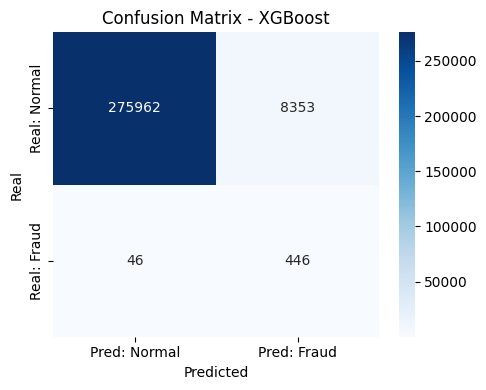



      SUMÁRIO FINAL - COMPARAÇÃO DOS MODELOS      
(Métricas médias calculadas a partir dos 5 folds do Nested CV)
                    mean_roc_auc  mean_precision  ...  std_recall  std_f1_score
RandomForest            0.976442        0.067615  ...    0.022812      0.024727
LogisticRegression      0.981208        0.085761  ...    0.034792      0.058670
KNN                     0.973882        0.073932  ...    0.022401      0.008622
XGBoost                 0.979501        0.051043  ...    0.016202      0.008506

[4 rows x 8 columns]


In [0]:
resultados_undersampling = avaliar_modelos_nested_cv(models_to_run_undersampling, X, y, plot_cm=True)

In [0]:
resultados_undersampling

,mean_roc_auc,mean_precision,mean_recall,mean_f1_score,std_roc_auc,std_precision,std_recall,std_f1_score
RandomForest,0.976442,0.067615,0.896310,0.125422,0.008275,0.014230,0.022812,0.024727
LogisticRegression,0.981208,0.085761,0.890229,0.154030,0.006608,0.035422,0.034792,0.058670
KNN,0.973882,0.073932,0.878005,0.136299,0.005768,0.005177,0.022401,0.008622
XGBoost,0.979501,0.051043,0.906514,0.096614,0.007928,0.004708,0.016202,0.008506




      INICIANDO AVALIAÇÃO: RandomForest      


RandomForest - Fold Externo 1/5
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Melhores parâmetros: {'model__max_depth': None, 'model__min_samples_leaf': 10, 'model__n_estimators': 300}
Fold 1 - ROC-AUC: 0.9904 | Avg. Precision: 0.8350 | Recall: 0.8283 | Precision: 0.7664 | F1: 0.7961


RandomForest - Fold Externo 2/5
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Melhores parâmetros: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Fold 2 - ROC-AUC: 0.9800 | Avg. Precision: 0.8596 | Recall: 0.8990 | Precision: 0.5057 | F1: 0.6473


RandomForest - Fold Externo 3/5
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Melhores parâmetros: {'model__max_depth': 7, 'model__min_samples_leaf': 10, 'model__n_estimators': 100}
Fold 3 - ROC-AUC: 0.9917 | Avg. Precision: 0.7995 | Recall: 0.8571 | Precision: 0.3529 | F1: 0.5000


RandomForest - Fold Externo 4/5
Fitting 5 folds

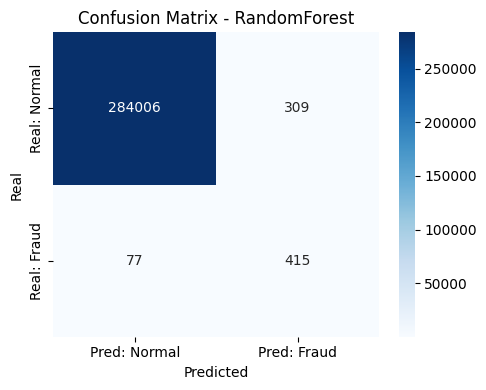



      INICIANDO AVALIAÇÃO: LogisticRegression      


LogisticRegression - Fold Externo 1/5
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores parâmetros: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Fold 1 - ROC-AUC: 0.9878 | Avg. Precision: 0.7112 | Recall: 0.8990 | Precision: 0.0666 | F1: 0.1240


LogisticRegression - Fold Externo 2/5
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores parâmetros: {'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Fold 2 - ROC-AUC: 0.9811 | Avg. Precision: 0.7158 | Recall: 0.9495 | Precision: 0.0609 | F1: 0.1145


LogisticRegression - Fold Externo 3/5
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores parâmetros: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Fold 3 - ROC-AUC: 0.9779 | Avg. Precision: 0.7154 | Recall: 0.9184 | Precision: 0.0579 | F1: 0.1089


LogisticRegression - Fold Externo 4/5
Fitting 5 folds for e

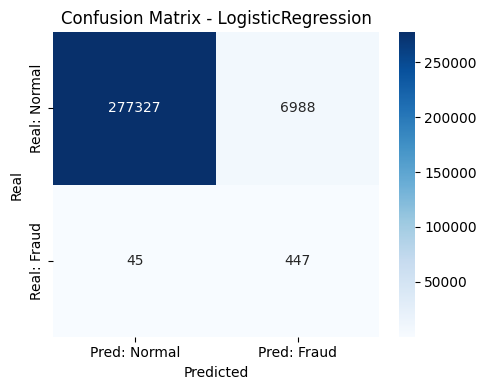



      INICIANDO AVALIAÇÃO: KNN      


KNN - Fold Externo 1/5
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Melhores parâmetros: {'model__n_neighbors': 7, 'model__weights': 'distance'}
Fold 1 - ROC-AUC: 0.9338 | Avg. Precision: 0.6019 | Recall: 0.8485 | Precision: 0.4516 | F1: 0.5895


KNN - Fold Externo 2/5
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Melhores parâmetros: {'model__n_neighbors': 7, 'model__weights': 'distance'}
Fold 2 - ROC-AUC: 0.9440 | Avg. Precision: 0.6890 | Recall: 0.8889 | Precision: 0.4293 | F1: 0.5789


KNN - Fold Externo 3/5
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Melhores parâmetros: {'model__n_neighbors': 7, 'model__weights': 'uniform'}
Fold 3 - ROC-AUC: 0.9382 | Avg. Precision: 0.6333 | Recall: 0.8469 | Precision: 0.3689 | F1: 0.5139


KNN - Fold Externo 4/5
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Melhores parâmetros: {'model__n_neighbors': 7, 'model__weights': 'uniform'}
Fold 4 - ROC-AU

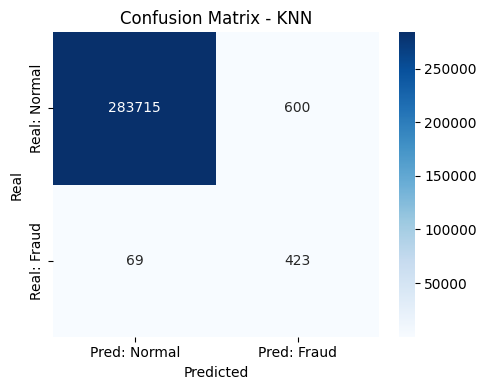



      INICIANDO AVALIAÇÃO: XGBoost      


XGBoost - Fold Externo 1/5
Fitting 5 folds for each of 432 candidates, totalling 2160 fits


In [0]:
resultados_oversampling = avaliar_modelos_nested_cv(models_to_run_oversampling, X, y, plot_cm=True)